In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import rfitools
import importlib
importlib.reload(rfitools)

<module 'rfitools' from '/home/mohanagr/Jupyter/MARS Fringe analysis (Summer 2025)/rfitools.py'>

In [2]:
plt.rcParams.update({
    # Figure & Resolution
    'figure.figsize': (4, 2),      # Standard rectangular size
    'figure.dpi': 100,             # High resolution for saving
    'savefig.dpi': 300,            # High resolution for exported images
    'savefig.bbox': 'tight',       # Removes unnecessary white space around the plot
    
    # Fonts & Text
    'font.family': 'sans-serif',   # Use serif for traditional journals, sans-serif for modern
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,               # Base font size
    'axes.titlesize': 10,          # Title size
    'axes.labelsize': 10,          # X and Y label size
    'xtick.labelsize': 10,         # Tick label size
    'ytick.labelsize': 10,         # Tick label size
    'legend.fontsize': 10,         # Legend text size
    
    # Axes & Spines (The "Clean" Look)
    'axes.spines.top': False,      # Remove top bounding box line
    'axes.spines.right': False,    # Remove right bounding box line
    'axes.linewidth': 1.1,         # Slightly thicker axes lines
    'axes.grid': False,            # Default to no grid (turn on manually if needed)
    
    # Ticks
    'xtick.direction': 'in',       # Ticks point inward
    'ytick.direction': 'in',       # Ticks point inward
    'xtick.major.size': 6,         # Major tick length
    'xtick.major.width': 1.2,      # Major tick thickness
    'ytick.major.size': 6,         # Major tick length
    'ytick.major.width': 1.2,      # Major tick thickness
    
    # Lines & Markers
    'lines.linewidth': 1.5,        # Thicker lines for visibility
    'lines.markersize': 4,         # Standard marker size
    
    # Legend
    'legend.frameon': False,       # Remove the box around the legend
    'legend.loc': 'best'           # Automatically place legend out of the way
})

In [3]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [79]:
tstart = 1753402150
ras = ['23h23m27.94s', '19h 59m 28.3566s']
decs = ['58d48m42.4s', "40° 44′ 02.096″"]
obstime=Time(tstart+np.arange(86400),format="unix",scale="utc")
casA = SkyCoord(ra=ras[0],dec=decs[0], frame='icrs') 
cygA = SkyCoord(ra=ras[1],dec=decs[1], frame='icrs') 
altaz_casA = casA.transform_to(AltAz(location=ant0,obstime=obstime))
altaz_cygA = cygA.transform_to(AltAz(location=ant0,obstime=obstime))

In [80]:
#now let's get back to ha, dec (apparent sources)
hadec_casA0 = rfitools.azalt_to_hadec(altaz_casA[0].az.rad, altaz_casA[0].alt.rad, ant0.lat.rad)
hadec_cygA0 = rfitools.azalt_to_hadec(altaz_cygA[0].az.rad, altaz_cygA[0].alt.rad, ant0.lat.rad)

In [81]:
d_ha = 7.29211e-5 #rad/s
myha_casA = np.arange(86400)*d_ha + hadec_casA0[0]
myha_cygA = np.arange(86400)*d_ha + hadec_cygA0[0]
#track these app. sources through the day

In [82]:
est_azalt_casA = rfitools.hadec_to_azalt(myha_casA, hadec_casA0[1], ant0.lat.rad)
est_azalt_cygA = rfitools.hadec_to_azalt(myha_cygA, hadec_cygA0[1], ant0.lat.rad)

(0.0, 200.0)

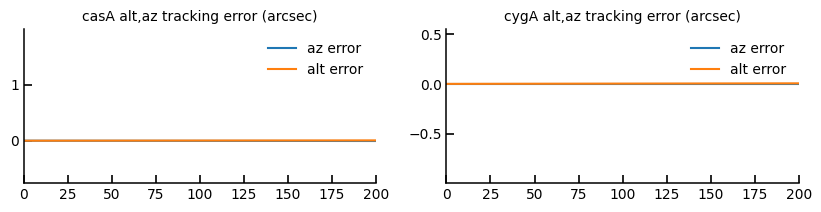

In [8]:
fig=plt.gcf()
fig.set_size_inches(10,2)
plt.subplot(121)
plt.title("casA alt,az tracking error (arcsec)")
plt.plot(np.rad2deg(est_azalt_casA[0] % (2*np.pi) - altaz_casA.az.rad % (2*np.pi))*3600,label='az error')
plt.plot(np.rad2deg(est_azalt_casA[1] % (2*np.pi) - altaz_casA.alt.rad % (2*np.pi))*3600,label='alt error')
plt.legend()
plt.xlim(0,200)
plt.subplot(122)
plt.title("cygA alt,az tracking error (arcsec)")
plt.plot(np.rad2deg(est_azalt_cygA[0] % (2*np.pi) - altaz_cygA.az.rad % (2*np.pi))*3600,label='az error')
plt.plot(np.rad2deg(est_azalt_cygA[1] % (2*np.pi) - altaz_cygA.alt.rad % (2*np.pi))*3600,label='alt error')
plt.legend()
plt.xlim(0,200)

In [83]:
bl_enu = rfitools.get_all_bls(coords, enu=True)
bl_itrs = rfitools.get_all_bls(coords, enu=False)

(21, 3)
(21, 3)


(-5e-12, 5e-12)

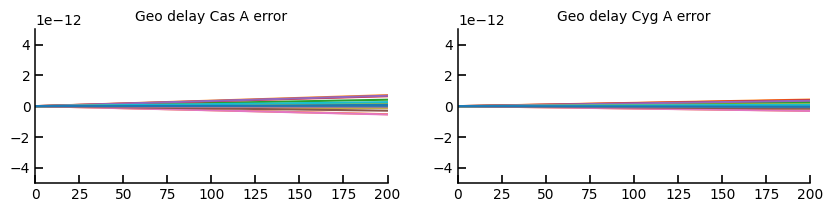

In [71]:
fig=plt.gcf()
fig.set_size_inches(10,2)

delays_from_enu = rfitools.geo_delay_from_enu(bl_enu, altaz_casA.az.rad, altaz_casA.alt.rad)
decs = np.ones(len(obstime),dtype='float64')*hadec_casA0[1]
delays_from_itrs = rfitools.geo_delay_from_itrs(bl_itrs, myha_casA, decs, ant0.lon.rad)
# delays_from_itrs = rfitools.geo_delay_from_enu(bl_enu, est_azalt_casA[0] , est_azalt_casA[1]) #this and above is same

plt.subplot(121)
plt.title("Geo delay Cas A error")
plt.plot(delays_from_enu.T-delays_from_itrs.T)
plt.xlim(0,200)
plt.ylim(-5e-12,5e-12)

delays_from_enu = rfitools.geo_delay_from_enu(bl_enu, altaz_cygA.az.rad, altaz_cygA.alt.rad)
decs = np.ones(len(obstime),dtype='float64')*hadec_cygA0[1]
delays_from_itrs = rfitools.geo_delay_from_itrs(bl_itrs, myha_cygA, decs, ant0.lon.rad)

plt.subplot(122)
plt.title("Geo delay Cyg A error")
plt.plot(delays_from_enu.T-delays_from_itrs.T)
plt.xlim(0,200)
plt.ylim(-5e-12,5e-12)

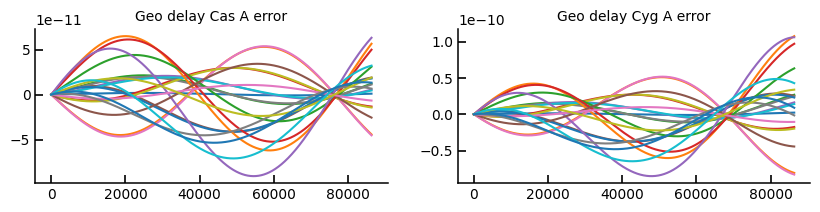

In [78]:
fig=plt.gcf()
fig.set_size_inches(10,2)

delays_from_enu = rfitools.geo_delay_from_enu(bl_enu, altaz_casA.az.rad, altaz_casA.alt.rad)
decs = np.ones(len(obstime),dtype='float64')*hadec_casA0[1]
# delays_from_itrs = rfitools.geo_delay_from_itrs(bl_itrs, myha_casA, decs, ant0.lon.rad)
delays_from_itrs = rfitools.geo_delay_from_enu(bl_enu, est_azalt_casA[0] , est_azalt_casA[1])

plt.subplot(121)
plt.title("Geo delay Cas A error")
plt.plot(delays_from_enu.T-delays_from_itrs.T)

delays_from_enu = rfitools.geo_delay_from_enu(bl_enu, altaz_cygA.az.rad, altaz_cygA.alt.rad)
decs = np.ones(len(obstime),dtype='float64')*hadec_cygA0[1]
# delays_from_itrs = rfitools.geo_delay_from_itrs(bl_itrs, myha_cygA, decs, ant0.lon.rad)
delays_from_itrs = rfitools.geo_delay_from_enu(bl_enu, est_azalt_cygA[0] , est_azalt_cygA[1]) #these two should be equiv.

plt.subplot(122)
plt.title("Geo delay Cyg A error")
plt.plot(delays_from_enu.T-delays_from_itrs.T)

In [85]:
#b dx cos(x) /c = dtau
#dx = c * dtau / b cos(x) x is zenith angle

np.rad2deg(3e8 * 1e-10 / 9e3 / np.cos(np.deg2rad(70)))*3600 # OOM lines up perfectly

np.float64(2.0102598270134897)

We'll start from t0 HA as 0 and then rotate baselines.

In [12]:
nbl = bl_itrs.shape[0]

In [88]:
ha,dec = hadec_casA0


In [89]:
hadec_casA0, myha_casA[0]

((np.float64(3.8978211401864966), np.float64(1.0288617443152532)),
 np.float64(3.8978211401864966))

In [54]:
ha,dec

(np.float64(3.8978211401864966), np.float64(1.0288617443152532))

In [90]:
gha = ha - ant0.lon.rad

In [107]:
gha

np.float64(5.482008308183315)

In [95]:
l,m,n = np.cos(gha)*np.cos(dec), -np.sin(gha)*np.cos(dec), np.sin(dec)

In [123]:
ntime = 1000
newdelays = np.zeros((nbl, ntime),dtype='float64')

for t in range(ntime):
    ph = t * 7.29211e-5
    sint = np.sin(ph)
    cost = np.cos(ph)
    # print("----",cost, sint,"----")
    for b in range(nbl):
        bx,by,bz = bl_itrs[b]
        bx2 = bx*cost - sint*by # 2d active rotation
        by2 = sint*bx + cost*by
        newdelays[b, t] = (l*bx2 + m*by2 + n*bz)/299792458

In [100]:
delays_from_enu = rfitools.geo_delay_from_enu(bl_enu, altaz_casA.az.rad, altaz_casA.alt.rad)
decs = np.ones(len(obstime),dtype='float64')*hadec_casA0[1]
delays_from_itrs = rfitools.geo_delay_from_itrs(bl_itrs, myha_casA, decs, ant0.lon.rad)

In [125]:
np.max(np.abs(newdelays[:,:ntime]-delays_from_enu[:,:ntime]))

np.float64(3.53774935778553e-12)

In [129]:
one_c = 1/299792458

In [1]:
n * bz * one_c

NameError: name 'n' is not defined

In [135]:
n.astype('float32') * bz.astype('float32') * np.float32(one_c)

np.float32(2.966767e-06)